# Dysarthria Detection from Audio using Deep Learning Techniques

## Imports

In [ ]:
import os

import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Reshape, LSTM, Flatten, Layer, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model, Model
from tensorflow.keras import backend as K
from keras_tuner import Hyperband
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import train_test_split

## Reading and Converting Data to MFCCs

In [4]:
SR = 16000
N_MFCC = 13
N_FFT = 1400
HOP_LENGTH = 160
SEGMENT_FRAMES = 320

MFCC_ROOT = "mfcc"


def extract_mfcc(y, sr):
    return librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )


def segment_mfcc(mfcc, segment_frames):
    segments = []
    total_frames = mfcc.shape[1]

    for start in range(0, total_frames, segment_frames):
        end = start + segment_frames
        segment = mfcc[:, start:end]

        if segment.shape[1] < segment_frames:
            pad_width = segment_frames - segment.shape[1]
            segment = np.pad(
                segment,
                pad_width=((0, 0), (0, pad_width)),
                mode="constant"
            )

        segments.append(segment)

    return np.array(segments)


def process_and_save(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if not filename.lower().endswith(".wav"):
            continue

        wav_path = os.path.join(input_folder, filename)

        y, sr = librosa.load(wav_path, sr=SR)
        mfcc = extract_mfcc(y, sr)
        mfcc_segments = segment_mfcc(mfcc, SEGMENT_FRAMES)

        save_name = filename.replace(".wav", ".npy")
        save_path = os.path.join(output_folder, save_name)

        np.save(save_path, mfcc_segments)


def load_mfcc_folder(folder, label):
    X, y = [], []

    for filename in os.listdir(folder):
        if not filename.lower().endswith(".npy"):
            continue

        file_path = os.path.join(folder, filename)
        mfcc_segments = np.load(file_path)   # (segments, 13, 320)

        for seg in mfcc_segments:
            X.append(seg)
            y.append(label)

    return np.array(X), np.array(y)

In [3]:
process_and_save(
    input_folder="data/dysarthria",
    output_folder="mfcc/dysarthria"
)

process_and_save(
    input_folder="data/non_dysarthria",
    output_folder="mfcc/non_dysarthria"
)

c:\Users\tailw\DataWorks\Dysarthria Detection\.venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1400 is too large for input signal of length=686
  warnings.warn(
c:\Users\tailw\DataWorks\Dysarthria Detection\.venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1400 is too large for input signal of length=421
  warnings.warn(
c:\Users\tailw\DataWorks\Dysarthria Detection\.venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1400 is too large for input signal of length=151
  warnings.warn(
c:\Users\tailw\DataWorks\Dysarthria Detection\.venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1400 is too large for input signal of length=134
  warnings.warn(
c:\Users\tailw\DataWorks\Dysarthria Detection\.venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1400 is too large for input signal of length=423
  warnings.warn(
c:\Users\tailw\DataWorks\Dysarthria Detection\.venv\lib\site-packages\libro

### Load MFCCs

In [5]:
X_dys, y_dys = load_mfcc_folder("mfcc/dysarthria", label=1)
X_non, y_non = load_mfcc_folder("mfcc/non_dysarthria", label=0)
X = np.concatenate((X_dys, X_non), axis=0)
y = np.concatenate((y_dys, y_non), axis=0)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

## Preparing Data for Deep Learning Model

In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2284, 13, 320), (2284,), (572, 13, 320), (572,))

In [8]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [9]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2284, 13, 320, 1), (2284,), (572, 13, 320, 1), (572,))

## Deep Learning Modeling and Evaluation

### ANN Model

In [10]:
X_train_ann = X_train.reshape(2284, 13 * 320)
X_test_ann = X_test.reshape(572, 13 * 320)

In [59]:
def build_model(hp):
    model = Sequential()

    model.add(Input(shape=(13 * 320,)))

    for i in range(hp.Int('num_layers', 1, 5)):

        model.add(Dense(hp.Int(f'units_{i}', min_value=64, max_value=512, step=32), activation='relu'))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

In [62]:
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=5,
    factor=3,
    directory='tuners',
    project_name='ann_tuners'
)

tuner.search(X_train_ann, y_train, validation_data=(X_test_ann, y_test), epochs=5)

Trial 10 Complete [00h 00m 08s]
val_accuracy: 0.7552447319030762

Best val_accuracy So Far: 0.7954545617103577
Total elapsed time: 00h 00m 57s


In [63]:
ann = tuner.get_best_models(num_models=1)[0]
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 384)            │     1,597,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 352)            │       135,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        33,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,773,505 (6.77 MB)

 Trainable params: 1,773,505 (6.77 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history = ann.fit(X_train_ann, y_train, epochs=15, validation_data=(X_test_ann, y_test))

Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6988 - loss: 1.0900 - val_accuracy: 0.6783 - val_loss: 0.6809
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7601 - loss: 0.5023 - val_accuracy: 0.7832 - val_loss: 0.4436
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7933 - loss: 0.4434 - val_accuracy: 0.7692 - val_loss: 0.4626
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8284 - loss: 0.3676 - val_accuracy: 0.7937 - val_loss: 0.4322
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8257 - loss: 0.3668 - val_accuracy: 0.6941 - val_loss: 0.6811
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8525 - loss: 0.3260 - val_accuracy: 0.7290 - val_loss: 0.5824
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8476 - loss: 0.3365 - val_accuracy: 0.7902 - val_loss: 0.4751
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8402 - loss: 0.3681 - val_accuracy: 0.7587 - v

In [65]:
ann.save("models/ann.keras")

### Model Evaluation

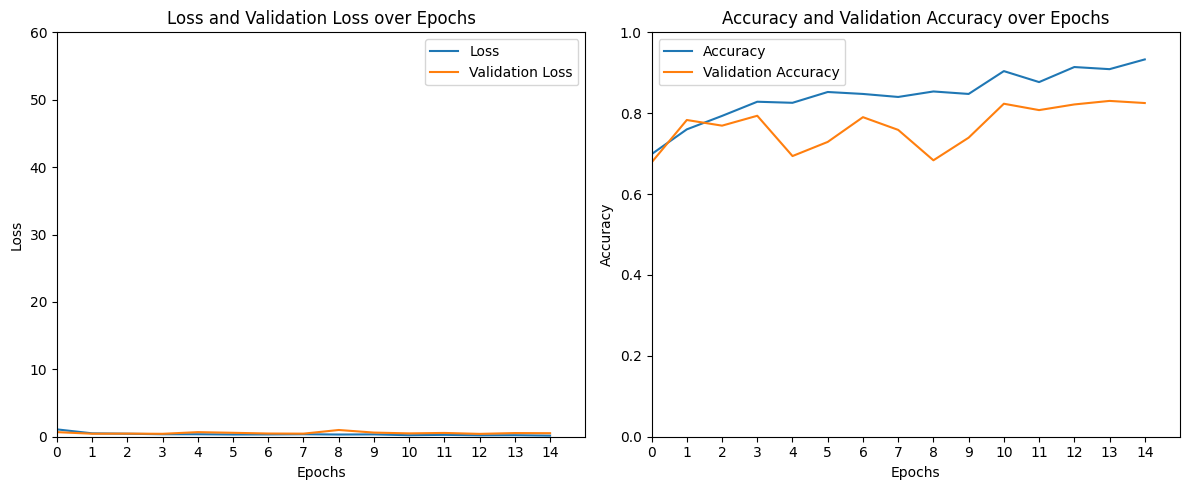

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['loss'], label='Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss and Validation Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_ylim(0, 60)
ax1.set_xlim(0, 15)
ax1.set_xticks(np.arange(0, 15, 1))
ax1.legend()

ax2.plot(history.history['accuracy'], label='Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Accuracy and Validation Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 15)
ax2.set_xticks(np.arange(0, 15, 1))
ax2.legend()

plt.tight_layout()
plt.show()

In [67]:
fig.savefig('models/ann_accuracy_loss_plots.png')

In [11]:
ann = load_model("models/ann.keras")

y_train_pred = (ann.predict(X_train_ann) > 0.5).astype("int32")
y_test_pred = (ann.predict(X_test_ann) > 0.5).astype("int32")

ann_train_confusion_matrix = confusion_matrix(y_train, y_train_pred)
ann_train_accuracy = round(accuracy_score(y_train, y_train_pred), 2)
ann_train_recall = round(recall_score(y_train, y_train_pred), 2)
ann_train_precision = round(precision_score(y_train, y_train_pred), 2)
ann_train_f1 = round(f1_score(y_train, y_train_pred), 2)

ann_test_confusion_matrix = confusion_matrix(y_test, y_test_pred)
ann_test_accuracy = round(accuracy_score(y_test, y_test_pred), 2)
ann_test_recall = round(recall_score(y_test, y_test_pred), 2)
ann_test_precision = round(precision_score(y_test, y_test_pred), 2)
ann_test_f1 = round(f1_score(y_test, y_test_pred), 2)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


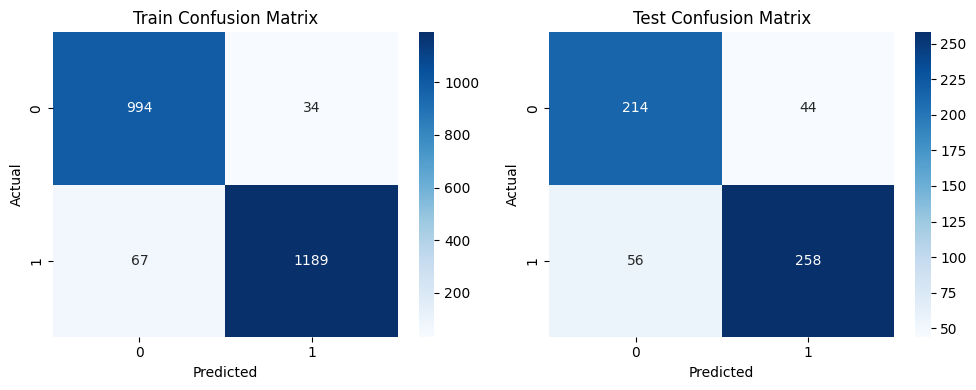

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(ann_train_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(ann_test_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [70]:
fig.savefig('models/ann_confusion_matrix.png')

### CNN Model

In [71]:
def build_model(hp):
    model = Sequential()
    
    model.add(Input(shape=(13, 320, 1)))

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Conv2D(
            filters=hp.Int('conv_1_filters', min_value=8, max_value=24, step=4),
            padding='same',
            kernel_size=(3, 3),
            activation='relu',
        ))
        model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [72]:
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=5,
    factor=3,
    directory='tuners',
    project_name='cnn_tuners'
)

tuner.search(X_train, y_train, validation_data=(X_test, y_test))

Trial 10 Complete [00h 00m 09s]
val_accuracy: 0.8181818127632141

Best val_accuracy So Far: 0.8216783404350281
Total elapsed time: 00h 01m 05s


In [73]:
cnn = tuner.get_best_models(num_models=1)[0]
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 320, 12)    │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 160, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,474,937 (5.63 MB)

 Trainable params: 1,474,937 (5.63 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
history = cnn.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7644 - loss: 2.1704 - val_accuracy: 0.8164 - val_loss: 0.6275
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8643 - loss: 0.4278 - val_accuracy: 0.6766 - val_loss: 2.1225
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8406 - loss: 0.5475 - val_accuracy: 0.8199 - val_loss: 0.6055
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9024 - loss: 0.2442 - val_accuracy: 0.7727 - val_loss: 0.8868
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8875 - loss: 0.3391 - val_accuracy: 0.8147 - val_loss: 0.8748
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8932 - loss: 0.2979 - val_accuracy: 0.7920 - val_loss: 0.7269
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9081 - loss: 0.2562 - val_accuracy: 0.7920 - val_loss: 0.7359
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9221 - loss: 0.2002 - val_accuracy: 0.8059 - v

In [75]:
cnn.save("models/cnn.keras")

### Model Evaluation

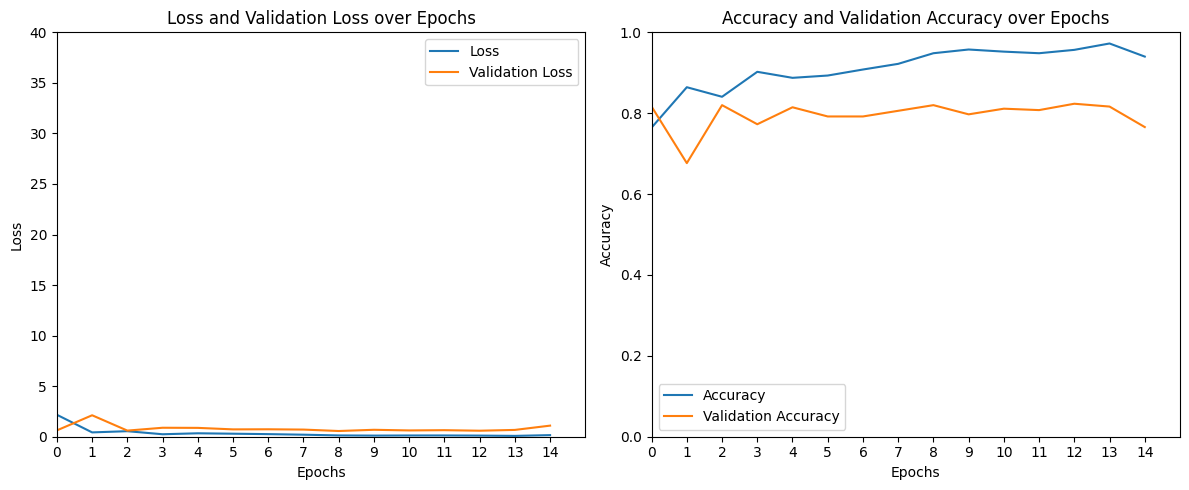

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['loss'], label='Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss and Validation Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_ylim(0, 40)
ax1.set_xlim(0, 15)
ax1.set_xticks(np.arange(0, 15, 1))
ax1.legend()

ax2.plot(history.history['accuracy'], label='Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Accuracy and Validation Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 15)
ax2.set_xticks(np.arange(0, 15, 1))
ax2.legend()

plt.tight_layout()
plt.show()

In [77]:
fig.savefig('models/cnn_accuracy_loss_plots.png')

In [12]:
cnn = load_model("models/cnn.keras")

y_train_pred = (cnn.predict(X_train) > 0.5).astype("int32")
y_test_pred = (cnn.predict(X_test) > 0.5).astype("int32")

cnn_train_confusion_matrix = confusion_matrix(y_train, y_train_pred)
cnn_train_accuracy = round(accuracy_score(y_train, y_train_pred), 2)
cnn_train_recall = round(recall_score(y_train, y_train_pred), 2)
cnn_train_precision = round(precision_score(y_train, y_train_pred), 2)
cnn_train_f1 = round(f1_score(y_train, y_train_pred), 2)

cnn_test_confusion_matrix = confusion_matrix(y_test, y_test_pred)
cnn_test_accuracy = round(accuracy_score(y_test, y_test_pred), 2)
cnn_test_recall = round(recall_score(y_test, y_test_pred), 2)
cnn_test_precision = round(precision_score(y_test, y_test_pred), 2)
cnn_test_f1 = round(f1_score(y_test, y_test_pred), 2)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


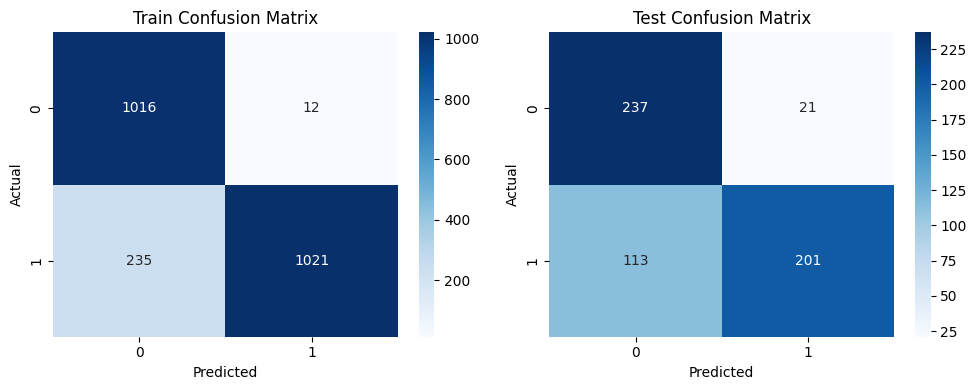

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(cnn_train_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cnn_test_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [80]:
fig.savefig('models/cnn_confusion_matrix.png')

### CNN-LSTM Model

In [86]:
def build_model(hp):
    layer_count = 0
    model = Sequential()
    
    model.add(Input(shape=(13, 320, 1)))

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Conv2D(
            hp.Int(f'filters_{i}', min_value=8, max_value=32, step=4),
            (3, 3),
            padding='same',
            activation='relu'
        ))
        layer_count += 1
    
    model.add(Reshape((-1, 320)))
    layer_count += 1

    for i in range(hp.Int('num_layers', 1, 2)):
        model.add(LSTM(
            hp.Int(f'lstm_units_{layer_count + i}', min_value=8, max_value=32, step=4),
            return_sequences=True
        ))
        layer_count += 1
    
    model.add(LSTM(
        hp.Int(f'lstm_units{layer_count}', min_value=8, max_value=32, step=4),
        return_sequences=False
    ))

    model.add(Dense(128, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2)),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [87]:
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=5,
    factor=3,
    directory='tuners',
    project_name='hybrid_tuners'
)

tuner.search(X_train, y_train, validation_data=(X_test, y_test))

Trial 10 Complete [00h 01m 11s]
val_accuracy: 0.7569929957389832

Best val_accuracy So Far: 0.7797203063964844
Total elapsed time: 00h 05m 49s


In [88]:
hybrid = tuner.get_best_models(num_models=1)[0]
hybrid.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 320, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 320, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 416, 320)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 416, 16)        │        21,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 416, 20)        │         2,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24)             │         4,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,977 (144.44 KB)

 Trainable params: 36,977 (144.44 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
history = hybrid.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.7596 - loss: 0.5128 - val_accuracy: 0.7640 - val_loss: 0.5108
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - accuracy: 0.7846 - loss: 0.4788 - val_accuracy: 0.7448 - val_loss: 0.5264
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 185ms/step - accuracy: 0.7912 - loss: 0.4657 - val_accuracy: 0.7990 - val_loss: 0.4640
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 183ms/step - accuracy: 0.7938 - loss: 0.4420 - val_accuracy: 0.7955 - val_loss: 0.4639
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 183ms/step - accuracy: 0.7885 - loss: 0.4460 - val_accuracy: 0.7832 - val_loss: 0.4858
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 188ms/step - accuracy: 0.7750 - loss: 0.4869 - val_accuracy: 0.7657 - val_loss: 0.5029
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - accuracy: 0.8012 - loss: 0.4469 - val_accuracy: 0.7937 - val_loss: 0.4842
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - accuracy: 0.7894 - loss: 0.4482 - val_accu

In [90]:
hybrid.save("models/hybrid.keras")

### Model Evaluation

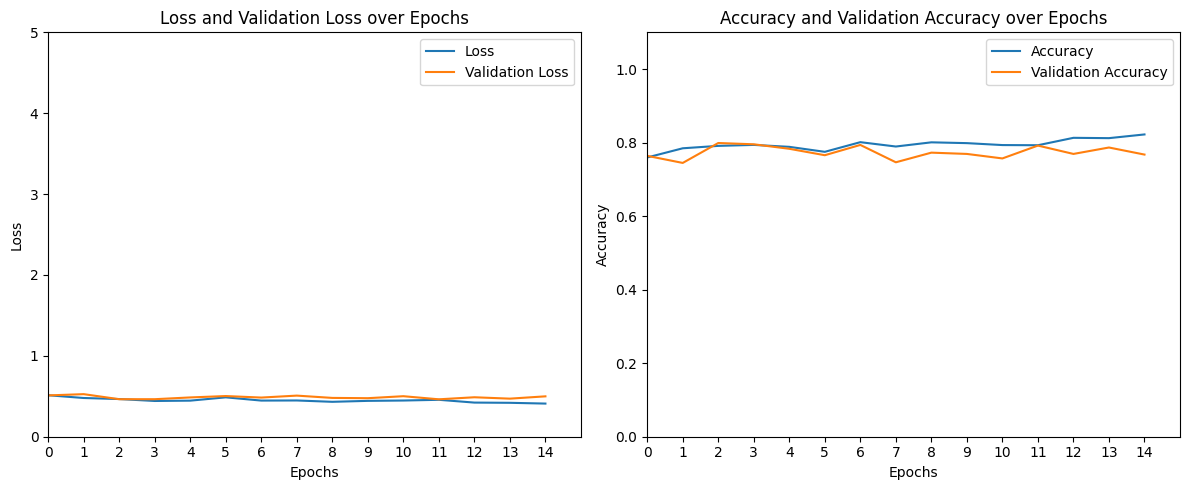

In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['loss'], label='Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss and Validation Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_ylim(0, 5)
ax1.set_xlim(0, 15)
ax1.set_xticks(np.arange(0, 15, 1))
ax1.legend()

ax2.plot(history.history['accuracy'], label='Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Accuracy and Validation Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.1)
ax2.set_xlim(0, 15)
ax2.set_xticks(np.arange(0, 15, 1))
ax2.legend()

plt.tight_layout()
plt.show()

In [92]:
fig.savefig('models/hybrid_accuracy_loss_plots.png')

In [13]:
hybrid = load_model("models/hybrid.keras")

y_train_pred = (hybrid.predict(X_train) > 0.5).astype("int32")
y_test_pred = (hybrid.predict(X_test) > 0.5).astype("int32")

hybrid_train_confusion_matrix = confusion_matrix(y_train, y_train_pred)
hybrid_train_accuracy = round(accuracy_score(y_train, y_train_pred), 2)
hybrid_train_recall = round(recall_score(y_train, y_train_pred), 2)
hybrid_train_precision = round(precision_score(y_train, y_train_pred), 2)
hybrid_train_f1 = round(f1_score(y_train, y_train_pred), 2)

hybrid_test_confusion_matrix = confusion_matrix(y_test, y_test_pred)
hybrid_test_accuracy = round(accuracy_score(y_test, y_test_pred), 2)
hybrid_test_recall = round(recall_score(y_test, y_test_pred), 2)
hybrid_test_precision = round(precision_score(y_test, y_test_pred), 2)
hybrid_test_f1 = round(f1_score(y_test, y_test_pred), 2)

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


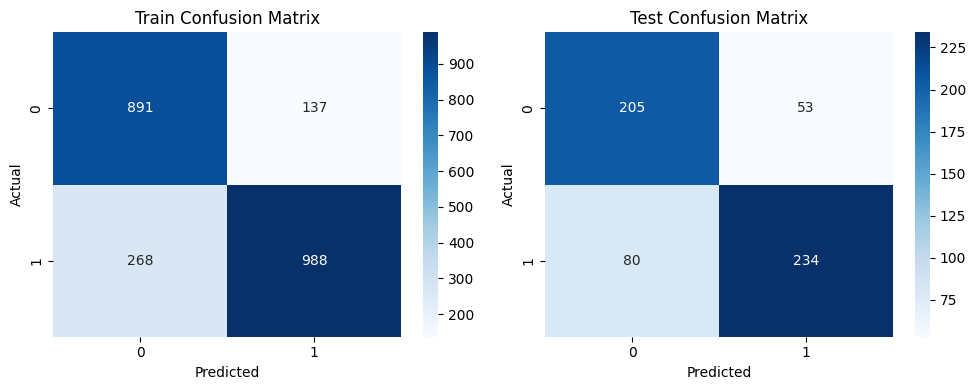

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(hybrid_train_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(hybrid_test_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [15]:
fig.savefig('models/hybrid_confusion_matrix.png')

## CapsNet

### Squashing Function

In [96]:
def squash(vectors, axis=-1):
    s_squared_norm = K.sum(K.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm) / K.sqrt(s_squared_norm + K.epsilon())
    return scale * vectors

### Primary Caps

In [97]:
def PrimaryCaps(inputs, dim_capsule, n_channels, kernel_size, strides, padding):
    x = Conv2D(
        filters=dim_capsule * n_channels,
        kernel_size=kernel_size,
        strides=strides,
        padding=padding,
        activation='relu'
    )(inputs)

    x = Reshape(target_shape=[-1, dim_capsule])(x)
    return Lambda(squash)(x)

### Class Capsule and Dynamic Routing

In [98]:
class CapsuleLayer(Layer):
    def __init__(self, num_capsules, dim_capsule, routing_iters=3, **kwargs):
        super().__init__(**kwargs)
        self.num_capsules = num_capsules
        self.dim_capsule = dim_capsule
        self.routing_iters = routing_iters

    def build(self, input_shape):
        self.input_num_capsules = input_shape[1]
        self.input_dim_capsule = input_shape[2]

        self.W = self.add_weight(
            shape=(self.input_num_capsules,
                   self.num_capsules,
                   self.input_dim_capsule,
                   self.dim_capsule),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, inputs):
        inputs_expand = tf.expand_dims(inputs, 2)
        inputs_tile = tf.tile(inputs_expand, [1, 1, self.num_capsules, 1])

        u_hat = tf.einsum('bijc,ijcd->bijd', inputs_tile, self.W)

        b = tf.zeros_like(u_hat[..., 0])

        for i in range(self.routing_iters):
            c = tf.nn.softmax(b, axis=2)
            s = tf.reduce_sum(c[..., None] * u_hat, axis=1)
            v = squash(s)

            if i < self.routing_iters - 1:
                b += tf.reduce_sum(u_hat * v[:, None, :, :], axis=-1)

        return v

### Margin Loss

In [99]:
def margin_loss(y_true, y_pred):
    m_plus = 0.9
    m_minus = 0.1
    lambda_val = 0.5

    L = y_true * K.square(K.maximum(0., m_plus - y_pred)) + lambda_val * (1 - y_true) * K.square(K.maximum(0., y_pred - m_minus))

    return K.mean(K.sum(L, axis=1))

### Modeling

In [103]:
def build_capsnet_model(hp):
    input_shape = (13, 320, 1)
    num_classes = 2

    inputs = Input(shape=input_shape)
    x = inputs

    for i in range(hp.Int('num_layers', min_value=1, max_value=3)):
        x = Conv2D(
            filters=hp.Int(f'conv_{i}_filters', min_value=8, max_value=32, step=8),
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        )(x)

    primary_caps = PrimaryCaps(
        x,
        dim_capsule=hp.Choice('primary_dim', [4, 8]),
        n_channels=hp.Choice('primary_channels', [8, 16]),
        kernel_size=(3, 3),
        strides=2,
        padding='same'
    )

    class_caps = CapsuleLayer(
        num_capsules=num_classes,
        dim_capsule=hp.Choice('class_dim', [8, 16]),
        routing_iters=hp.Int('routing_iters', 2, 3)
    )(primary_caps)

    outputs = Lambda(
        lambda z: K.sqrt(K.sum(K.square(z), axis=-1)),
        name='capsnet_output'
    )(class_caps)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float('lr', 1e-4, 1e-3, sampling='log')
        ),
        loss=margin_loss,
        metrics=['accuracy']
    )

    return model

In [106]:
tuner = Hyperband(
    build_capsnet_model,
    objective='val_accuracy',
    max_epochs=5,
    factor=3,
    directory='tuners',
    project_name='capsnet_tuners'
)

In [107]:
tuner.search(
    X_train,
    tf.keras.utils.to_categorical(y_train, 2),
    validation_data=(
        X_test,
        tf.keras.utils.to_categorical(y_test, 2)
    ),
    batch_size=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Trial 10 Complete [00h 04m 55s]
val_accuracy: 0.8164335489273071

Best val_accuracy So Far: 0.9038461446762085
Total elapsed time: 00h 42m 18s


### Best Model

In [108]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
capsnet = tuner.hypermodel.build(best_hp)
capsnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 13, 320, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 320, 24)    │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 160, 32)     │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8960, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 8960, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsule_layer_1 (CapsuleLayer)  │ (None, 2, 16)          │     1,146,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsnet_output (Lambda)         │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,154,064 (4.40 MB)

 Trainable params: 1,154,064 (4.40 MB)

 Non-trainable params: 0 (0.00 B)

In [109]:
history = capsnet.fit(
    X_train,
    tf.keras.utils.to_categorical(y_train, 2),
    validation_data=(
        X_test,
        tf.keras.utils.to_categorical(y_test, 2)
    ),
    epochs=20,
    batch_size=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 59s 202ms/step - accuracy: 0.6821 - loss: 0.2192 - val_accuracy: 0.8234 - val_loss: 0.1176
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 56s 195ms/step - accuracy: 0.8949 - loss: 0.0883 - val_accuracy: 0.8741 - val_loss: 0.0904
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 61s 212ms/step - accuracy: 0.9562 - loss: 0.0500 - val_accuracy: 0.8829 - val_loss: 0.0887
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 59s 205ms/step - accuracy: 0.9781 - loss: 0.0335 - val_accuracy: 0.8899 - val_loss: 0.0840
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 57s 199ms/step - accuracy: 0.9799 - loss: 0.0259 - val_accuracy: 0.8934 - val_loss: 0.0813
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 56s 197ms/step - accuracy: 0.9869 - loss: 0.0217 - val_accuracy: 0.8899 - val_loss: 0.0836
Epoch 7/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 62s 216ms/step - accuracy: 0.9882 - loss: 0.0203 - val_accuracy: 0.8881 - val_loss: 0.0894
Epoch 8/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 58s 204ms/step - accuracy: 0.9912 - loss: 0

In [110]:
capsnet.save("models/capsnet.keras")

### Evaluation

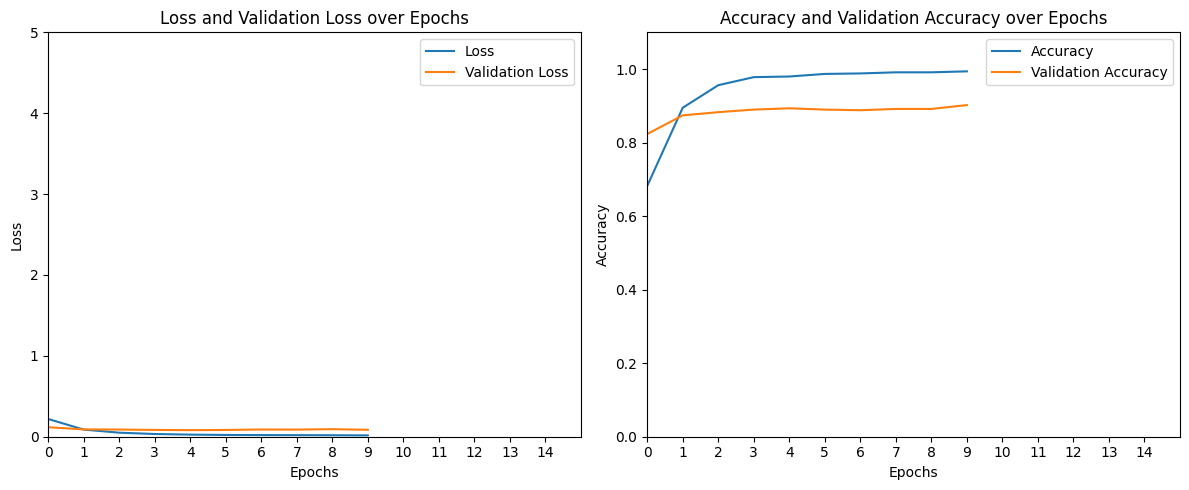

In [111]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['loss'], label='Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss and Validation Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_ylim(0, 5)
ax1.set_xlim(0, 15)
ax1.set_xticks(np.arange(0, 15, 1))
ax1.legend()

ax2.plot(history.history['accuracy'], label='Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Accuracy and Validation Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.1)
ax2.set_xlim(0, 15)
ax2.set_xticks(np.arange(0, 15, 1))
ax2.legend()

plt.tight_layout()
plt.show()

In [112]:
fig.savefig('models/capsnet_loss_plots.png')

In [113]:
y_train_prob = capsnet.predict(X_train)
y_test_prob = capsnet.predict(X_test)

y_train_pred = np.argmax(y_train_prob, axis=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

capsnet_train_confusion_matrix = confusion_matrix(y_train, y_train_pred)
capsnet_train_accuracy = round(accuracy_score(y_train, y_train_pred), 2)
capsnet_train_recall = round(recall_score(y_train, y_train_pred), 2)
capsnet_train_precision = round(precision_score(y_train, y_train_pred), 2)
capsnet_train_f1 = round(f1_score(y_train, y_train_pred), 2)

capsnet_test_confusion_matrix = confusion_matrix(y_test, y_test_pred)
capsnet_test_accuracy = round(accuracy_score(y_test, y_test_pred), 2)
capsnet_test_recall = round(recall_score(y_test, y_test_pred), 2)
capsnet_test_precision = round(precision_score(y_test, y_test_pred), 2)
capsnet_test_f1 = round(f1_score(y_test, y_test_pred), 2)

72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step


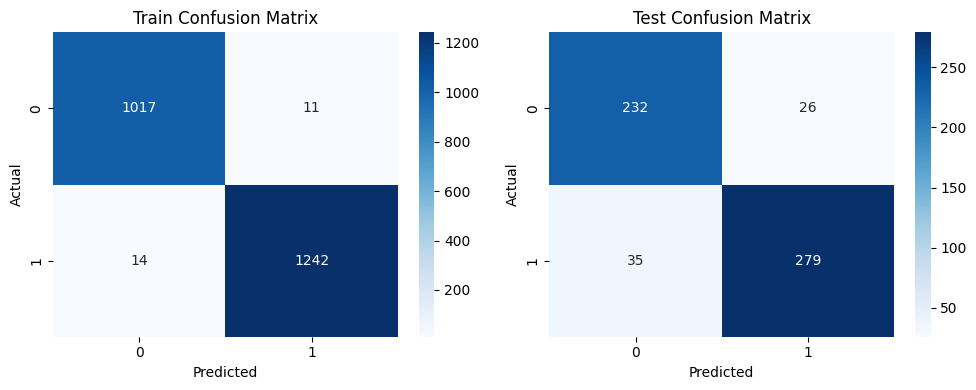

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(capsnet_train_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(capsnet_test_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
fig.savefig('models/capsnet_confusion_matrix.png')

## Comparison

In [116]:
import pandas as pd


data = {
    'Model': ['ANN', 'CNN', 'Hybrid', 'CapsNet'],
    'Train Accuracy': [ann_train_accuracy, cnn_train_accuracy, hybrid_train_accuracy, capsnet_train_accuracy],
    'Test Accuracy': [ann_test_accuracy, cnn_test_accuracy, hybrid_test_accuracy, capsnet_test_accuracy],
    'Train Precision': [ann_train_precision, cnn_train_precision, hybrid_train_precision, capsnet_train_precision],
    'Test Precision': [ann_test_precision, cnn_test_precision, hybrid_test_precision, capsnet_test_precision],
    'Train Recall': [ann_train_recall, cnn_train_recall, hybrid_train_recall, capsnet_train_recall],
    'Test Recall': [ann_test_recall, cnn_test_recall, hybrid_test_recall, capsnet_test_recall],
    'Train F1 Score': [ann_train_f1, cnn_train_f1, hybrid_train_f1, capsnet_train_f1],
    'Test F1 Score': [ann_test_f1, cnn_test_f1, hybrid_test_f1, capsnet_test_f1]
}


df = pd.DataFrame(data)
df

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score
0,ANN,0.96,0.83,0.97,0.85,0.95,0.82,0.96,0.84
1,CNN,0.89,0.77,0.99,0.91,0.81,0.64,0.89,0.75
2,Hybrid,0.82,0.77,0.88,0.82,0.79,0.75,0.83,0.78
3,CapsNet,0.99,0.89,0.99,0.91,0.99,0.89,0.99,0.90
